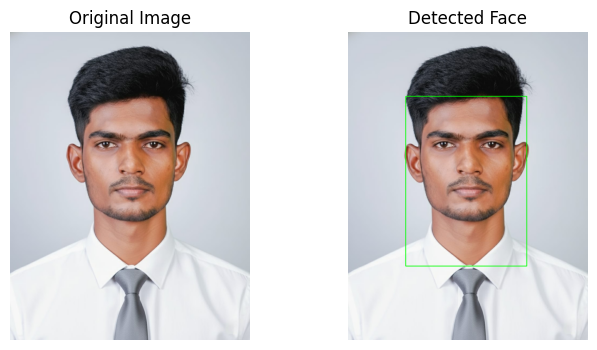

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Load Image
image = cv2.imread("test1.jpeg")  # your image
original = image.copy()

# Step 2: Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Step 3: Define skin color range (IMPORTANT)
lower = np.array([0, 40, 60], dtype=np.uint8)
upper = np.array([20, 150, 255], dtype=np.uint8)

# Step 4: Create mask
mask = cv2.inRange(hsv, lower, upper)

# Step 5: Morphological operations (clean noise)
kernel = np.ones((5,5), np.uint8)
mask = cv2.erode(mask, kernel, iterations=1)
mask = cv2.dilate(mask, kernel, iterations=2)

# Step 6: Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 7: Find largest contour (face)
if len(contours) > 0:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    cv2.rectangle(image, (x,y), (x+w, y+h), (0,255,0), 2)

# Step 8: Show Output
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Detected Face")
plt.axis('off')

plt.show()

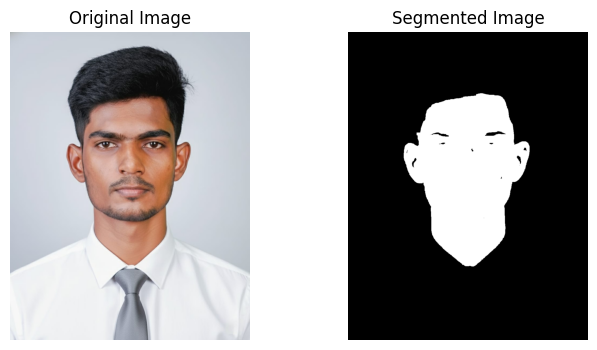

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Load Image
image = cv2.imread("test1.jpeg")
original = image.copy()

# Step 2: Convert to YCbCr
ycbcr = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

# Step 3: Define skin range (IMPORTANT)
lower = np.array([0, 133, 77], dtype=np.uint8)
upper = np.array([255, 173, 127], dtype=np.uint8)

# Step 4: Create mask
mask = cv2.inRange(ycbcr, lower, upper)

# Step 5: Morphological operations (clean)
kernel = np.ones((5,5), np.uint8)
mask = cv2.erode(mask, kernel, iterations=1)
mask = cv2.dilate(mask, kernel, iterations=2)

# Step 6: Display Output
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Segmented Image")
plt.axis('off')

plt.show()